In [1]:
# ============================================
# LIBRERÍAS REQUERIDAS
# ============================================
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
# ============================================
# 1. CARGAR DATOS DE CLIENTES
# ============================================
# Cargar dataset con métricas de CLV
df = pd.read_csv("./data/customer_clv.csv")

print("\n=== DATASET CARGADO ===\n")
print(f"Dimensiones: {df.shape[0]:,} clientes x {df.shape[1]} variables")
print("\nMuestras aleatorias:")
print(df.sample(5))


=== DATASET CARGADO ===

Dimensiones: 694,608 clientes x 26 variables

Muestras aleatorias:
          user_id  monetary  avg_ticket  frequency  total_views  total_carts  \
143295  516598535    916.37  916.370000          1            2            0   
660510  572622117    113.26   56.630000          2           11            5   
637874  571330329    194.10  194.100000          1            1            3   
393913  546057006     51.46   51.460000          1            4            1   
362512  542150135    492.67  164.223333          3           14            4   

        avg_time_view  avg_time_cart       first_purchase  \
143295    1095.796667            NaN  2019-11-29 07:56:37   
660510       0.360972       0.080417  2019-11-17 15:17:42   
637874       0.153611       0.121944  2019-11-14 07:47:16   
393913     216.187500       0.021389  2019-10-25 16:59:08   
362512       1.248333       0.119722  2019-10-31 06:43:26   

              last_purchase  ...  carts_per_purchase  view_

Selección de características para el modelo

In [3]:
# ============================================
# 2. SELECCIÓN DE CARACTERÍSTICAS
# ============================================
# Variables predictoras relevantes para modelo de CLV
features = [
    "recency",
    "total_views",
    "total_carts",
    "conversion_rate",
    "cart_rate",
    "views_per_purchase",
    "carts_per_purchase",
    "avg_time_between_purchases"
]

# Matriz de características y variable objetivo
X = df[features].fillna(0)
y = df["CLV"]

print(f"Características seleccionadas: {len(features)}")
print(f"Observaciones: {len(X):,}")

Características seleccionadas: 8
Observaciones: 694,608


Estandarización de variables

In [4]:
# ============================================
# 3. ESTANDARIZACIÓN DE CARACTERÍSTICAS
# ============================================
# Escalar variables para normalizar rangos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Modelado de CLV con Random Forest

División de datos Train/Test

In [5]:
# ============================================
# 4. DIVISIÓN DE DATOS
# ============================================
# Separar datos en entrenamiento y prueba (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=123
)

print(f"Datos de entrenamiento: {len(X_train):,}")
print(f"Datos de prueba: {len(X_test):,}")

Datos de entrenamiento: 555,686
Datos de prueba: 138,922


Entrenamiento del modelo

In [6]:
# ============================================
# 5. ENTRENAMIENTO DEL MODELO
# ============================================
# Modelo de Random Forest con 100 árboles
model = RandomForestRegressor(n_estimators=100, random_state=123)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=123)

Evaluación del modelo

In [7]:
# ============================================
# 6. EVALUACIÓN DEL DESEMPEÑO
# ============================================
# Realizar predicciones en datos de prueba
y_pred = model.predict(X_test)

# Calcular métricas de error
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n=== MÉTRICAS DEL MODELO ===\n")
print(f"MAE (Error Absoluto Medio): {mae:.2f}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.2f}")


=== MÉTRICAS DEL MODELO ===

MAE (Error Absoluto Medio): 504.14
RMSE (Raíz del Error Cuadrático Medio): 1462.34


In [8]:
# ============================================
# 7. ANÁLISIS DESCRIPTIVO DEL CLV
# ============================================
print("\n=== ESTADÍSTICAS DE CLV ===\n")
print(y.describe())


=== ESTADÍSTICAS DE CLV ===

count    694608.000000
mean        696.942273
std        2105.961905
min           0.770000
25%         117.090000
50%         256.550000
75%         656.035000
max      301617.620000
Name: CLV, dtype: float64


 - MAE ~= 504, sobre el CLV medio de 697 tenemos un error relativo de ~72%.
 - RMSE ~= 1462, esto nos indica que con media de 696, máximo de 301,617 y desviación de 2105 el error viene de outliers con valores muy altos.

El modelo funciona razonablemente bien para clientes medios. Pero falla en clientes de alto valor (outliers).

El CLV presenta una distribución altamente asimétrica, donde una pequeña proporción de clientes concentra gran parte del valor total. Esto dificulta la capacidad predictiva del modelo, especialmente en valores extremos.

In [9]:
# ============================================
# 8. IMPORTANCIA DE CARACTERÍSTICAS
# ============================================
# Ordenar características por importancia
importance = pd.Series(model.feature_importances_, index=features)
importance = importance.sort_values(ascending=False)

print("\n=== IMPORTANCIA DE VARIABLES ===\n")
print(importance)


=== IMPORTANCIA DE VARIABLES ===

total_views                   0.567151
avg_time_between_purchases    0.092751
conversion_rate               0.076524
total_carts                   0.063765
recency                       0.059434
carts_per_purchase            0.049399
cart_rate                     0.047402
views_per_purchase            0.043574
dtype: float64


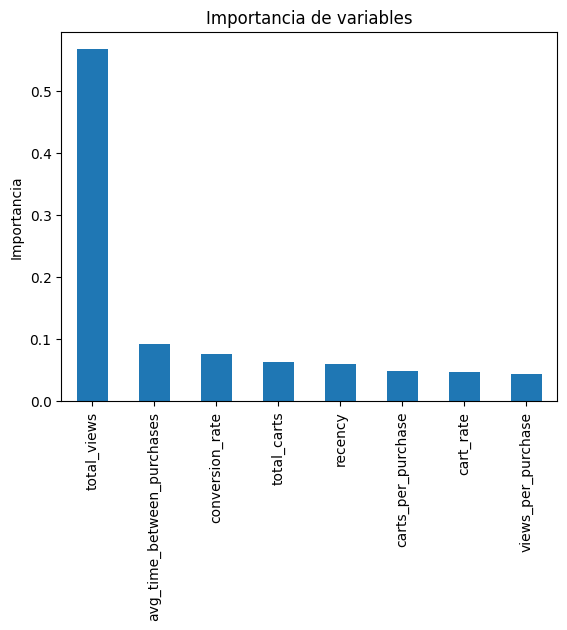

In [10]:
plt.figure()
importance.plot(kind="bar")
plt.title("Importancia de variables")
plt.ylabel("Importancia")
plt.show()

 - total_views

Es la variable más importante con diferencia ~56%
El volumen de interacción del usuario es el principal predictor del valor generado, indicando que el engagement es un factor clave en la generación de ingresos.

 - avg_time_between_purchases

Segunda variable más relevante ~9%
La frecuencia temporal de compra influye significativamente en el valor del cliente, siendo los clientes más recurrentes los más valiosos.

 - conversion_rate

Tercera variable más relevante ~7%
La eficiencia en el proceso de conversión (de visualización a compra) es un factor determinante del CLV.

 - total_carts

Cuarta variable más relevante ~6.3%
Refuerza el funnel, cuanta más intención más valor esperado

 - recency

Cuarta variable más relevante ~5.9%
La recencia actúa como indicador de actividad activa del cliente y está asociada a mayor valor futuro.

El modelo está capturando correctamente:
 - Engagement (views)
 - Intención (carts)
 - Conversión (ratios)
 - Frecuencia (tiempo entre compras)

Es decir es coherente con las nociones preconcevias de negocio.

Podemos notar algunas limitaciones:
 - Sensibilidad a outliers, CLV extremo distorsiona el modelo
 - Desbalance de la variable objetivo, muchos clientes de bajo valor, pocos de alto valor
 - Dominancia de una variable, total_views pesa demasiado

Para mejorar el caso de outliers por CLVtenemos algunas opciones:
 - Transformación logarítmica: y = np.log1p(df["CLV"])
 - Modelar segmentos por separado: clientes low / medium / high value
 - Feature adicional: nº de sesiones, diversidad de productos

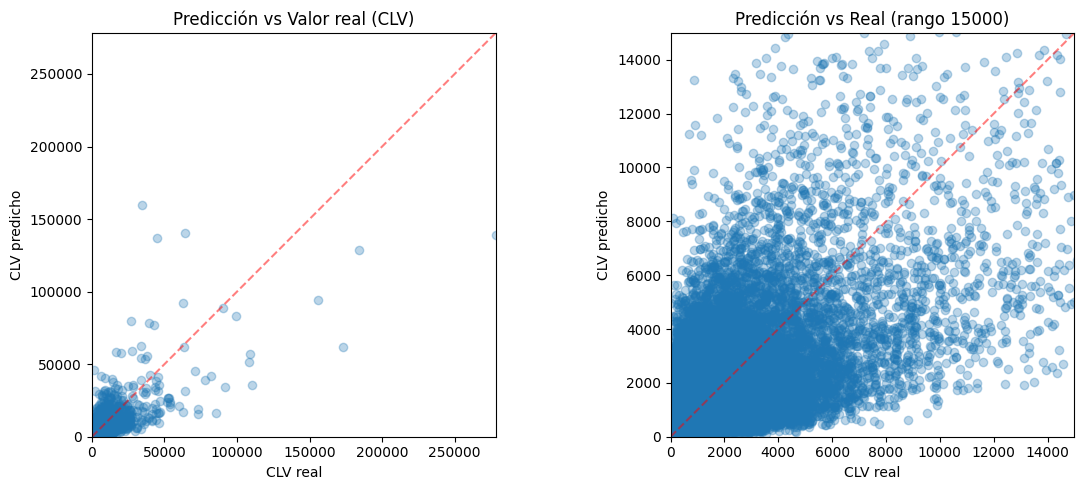

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Encontrar el valor máximo para establecer límites
max_valor_real = max(y_test.max(), y_test.max())
max_valor_pred = max(y_pred.max(), y_pred.max())
limite_max = max(max_valor_real, max_valor_pred)

# Primer gráfico
ax1.scatter(y_test, y_pred, alpha=0.3)
ax1.plot([0, limite_max], [0, limite_max], 'r--', alpha=0.5)  # Línea de referencia
ax1.set_title("Predicción vs Valor real (CLV)")
ax1.set_xlabel("CLV real")
ax1.set_ylabel("CLV predicho")
ax1.set_xlim(0, limite_max)
ax1.set_ylim(0, limite_max)
ax1.set_aspect('equal')

# Segundo gráfico
ax2.scatter(y_test, y_pred, alpha=0.3)
ax2.plot([0, limite_max], [0, limite_max], 'r--', alpha=0.5)  # Línea de referencia
ax2.set_title("Predicción vs Real (rango 15000)")
ax2.set_xlabel("CLV real")
ax2.set_ylabel("CLV predicho")
ax2.set_xlim(0, 15000)
ax2.set_ylim(0, 15000)
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

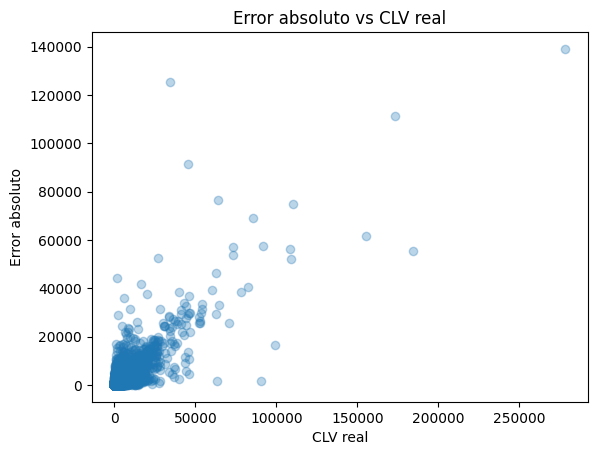

In [12]:
abs_errors = abs( y_test - y_pred)

plt.figure()
plt.scatter(y_test, abs_errors, alpha=0.3)
plt.title("Error absoluto vs CLV real")
plt.xlabel("CLV real")
plt.ylabel("Error absoluto")
plt.show()

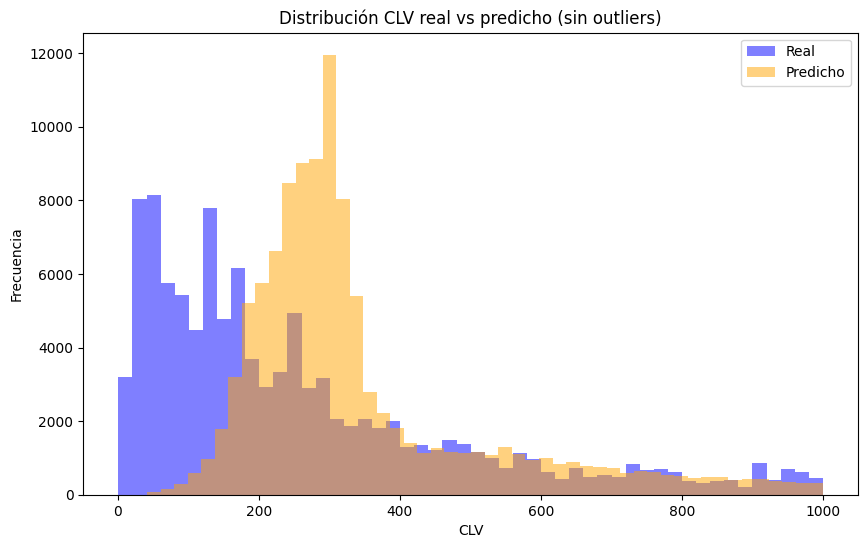

In [13]:
mask = (y_test < 1000) & (y_pred < 1000)

plt.figure(figsize=(10, 6))
plt.hist(y_test[mask], bins=50, alpha=0.5, label="Real", color='blue')
plt.hist(y_pred[mask], bins=50, alpha=0.5, label="Predicho", color='orange')
plt.title("Distribución CLV real vs predicho (sin outliers)")
plt.xlabel("CLV")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

El modelo presenta un rendimiento razonable, con un error medio coherente con la escala del problema, aunque afectado por la alta variabilidad del CLV.

Las variables más relevantes están relacionadas con el comportamiento del usuario, destacando especialmente el número de visualizaciones, lo que indica que el engagement es el principal motor del valor del cliente.

Asimismo, variables temporales y de conversión aportan capacidad explicativa adicional, confirmando que tanto la frecuencia como la eficiencia del proceso de compra influyen en el CLV.

No obstante, la presencia de valores extremos limita la precisión del modelo, lo que sugiere la necesidad de técnicas adicionales como transformaciones o segmentación para mejorar el rendimiento.